# PBL Fase 6 – Visão Computacional com YOLO
**Notebook:** João Pedro Zavanela Andreu · RM 570231 — `JoaoPedroZavanelaAndreu_rm570231_pbl_fase6.ipynb` (padrão do barema)
**Conteúdo (seções 1–7):** Patrick Borges Melo · RM 574030 · **Classes:** `vaca` (0) e `caminhao` (1)

> Rodar no Google Colab com GPU. As seções 2–7 dependem do dataset no Drive (`Espaço Matopiba / Fase 6 - Cap 1 / dataset`).

## 1. Ambiente (rodar no Google Colab, com GPU: *Ambiente de execução → Alterar tipo → GPU*)

In [1]:
# Monta o Google Drive da conta que executa o notebook: é onde vivem o dataset e a pasta de resultados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Clona o YOLOv5 só se ainda não estiver no disco (/content sobrevive ao "Reiniciar e executar tudo")
![ -d /content/yolov5 ] || git clone --depth 1 https://github.com/ultralytics/yolov5 /content/yolov5
# As células 18 e 20 usam caminhos relativos (runs/...), então o diretório de trabalho importa
%cd /content/yolov5
# Dependências do YOLOv5 (o Colab já traz torch/CUDA)
!pip install -q -r requirements.txt
# Confere a GPU: sem GPU o treino de 100 épocas fica inviável
import torch; print(torch.__version__, 'GPU:', torch.cuda.is_available())

Cloning into '/content/yolov5'...
remote: Enumerating objects: 18770, done.
remote: Counting objects: 100% (341/341), done.
remote: Compressing objects: 100% (201/201), done.
remote: Total 18770 (delta 276), reused 140 (delta 140), pack-reused 18429 (from 5)
Receiving objects: 100% (18770/18770), 17.77 MiB | 18.89 MiB/s, done.
Resolving deltas: 100% (12769/12769), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.0 MB/s eta 0:00:00
2.11.0+cu130 GPU: True


## 2. Dataset (Issues #1 e #2)
O dataset fica no Drive em *Espaço Matopiba / Fase 6 - Cap 1 / dataset*. Copiamos para o disco do Colab (mais rápido e evita problemas com espaços e acentos no caminho).

In [3]:
# Copia o dataset do Drive para o disco local do Colab (mais rápido e evita espaços/acentos no caminho)
import shutil, os
DRIVE_ROOT = '/content/drive/MyDrive/Espaço Matopiba/Fase 6 - Cap 1'  # pasta do projeto no Drive
DRIVE_DATASET = f'{DRIVE_ROOT}/dataset'
LOCAL = '/content/dataset'

# Falha com mensagem clara se o dataset não estiver no Drive (o notebook é reexecutado na correção)
assert os.path.isdir(DRIVE_DATASET), f'Dataset não encontrado em {DRIVE_DATASET}: suba images/ e labels/ com train, val e test'
if os.path.exists(LOCAL): shutil.rmtree(LOCAL)  # descarta a cópia anterior
shutil.copytree(DRIVE_DATASET, LOCAL)

# data.yaml com caminho do Colab (sobrescreve o do Drive, que aponta para outro caminho)
open(f'{LOCAL}/data.yaml','w').write(f'''path: {LOCAL}
train: images/train
val: images/val
test: images/test
nc: 2
names:
  0: vaca
  1: caminhao
''')
# Confere a estrutura: cada imagem precisa do seu .txt, e as contagens esperadas são 64 / 8 / 8
for s in ('train','val','test'):
    im = len(os.listdir(f'{LOCAL}/images/{s}')); lb = len(os.listdir(f'{LOCAL}/labels/{s}'))
    cx = [0, 0]  # caixas por classe (0 = vaca, 1 = caminhao): evidência da composição do dataset
    for arq in os.listdir(f'{LOCAL}/labels/{s}'):
        with open(f'{LOCAL}/labels/{s}/{arq}') as f:
            for linha in f:
                if linha.strip(): cx[int(linha.split()[0])] += 1
    print(s, 'imagens', im, 'labels', lb, '| caixas: vaca', cx[0], 'caminhao', cx[1])

train imagens 64 labels 64
val imagens 8 labels 8
test imagens 8 labels 8


Verificação rápida: cada imagem deve ter seu `.txt`, e as contagens esperadas são **64 / 8 / 8** (train/val/test).
A célula acima imprime também as **caixas por classe** — é dela que saem os totais usados nas conclusões.

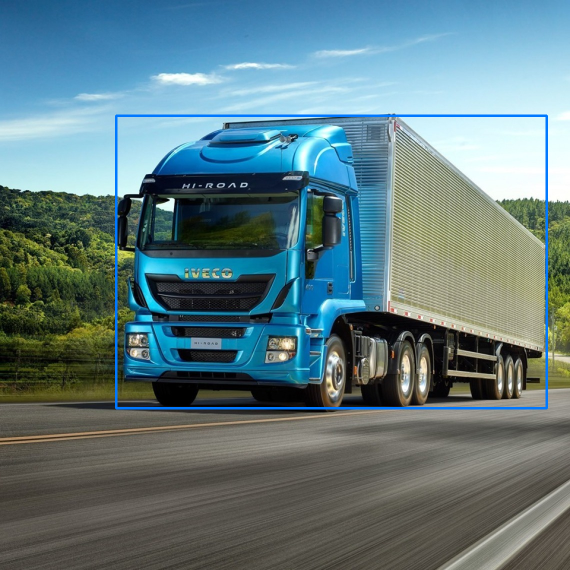

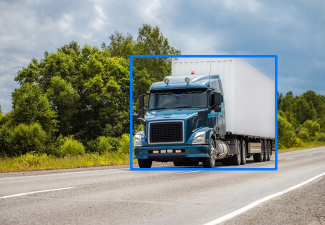

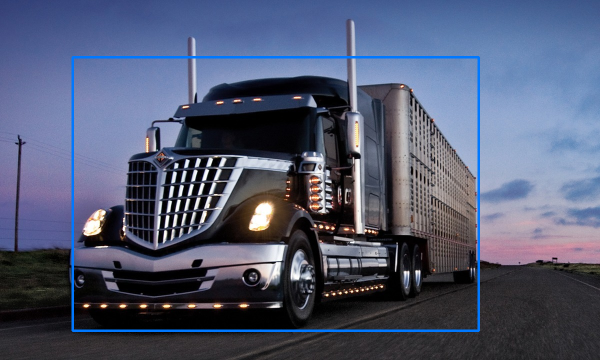

In [4]:
# Amostra visual: desenha as caixas rotuladas para conferir se o .txt casa com a imagem antes de treinar
import glob, os, random, cv2
from google.colab.patches import cv2_imshow
random.seed(0)  # amostra reprodutível entre execuções

def mostrar(split='train', n=3):
    """Mostra n imagens do split com as bounding boxes rotuladas (0 = vaca/vermelho, 1 = caminhão/azul)."""
    for p in random.sample(glob.glob(f'{LOCAL}/images/{split}/*'), n):
        im = cv2.imread(p); h, w = im.shape[:2]
        im = cv2.resize(im, (w//2, h//2))  # reduz antes de desenhar para a espessura não virar 1 pixel
        lab = os.path.splitext(p.replace('images', 'labels'))[0] + '.txt'  # aceita .jpg/.jpeg/.png
        for l in open(lab):
            c, cx, cy, bw, bh = l.split()  # classe cx cy w h (normalizados)
            cx, cy, bw, bh = float(cx)*w/2, float(cy)*h/2, float(bw)*w/2, float(bh)*h/2
            cv2.rectangle(im, (int(cx-bw/2), int(cy-bh/2)), (int(cx+bw/2), int(cy+bh/2)),
                          (0, 0, 255) if c == '0' else (255, 120, 0), 2)
        cv2_imshow(im)

mostrar()

## 3. YOLO tradicional (pré-treinado no COCO, sem treinar)
O COCO já tem `cow` (19) e `truck` (7). Rodamos o baseline **filtrado nessas duas classes** (`--classes 19 7`) para comparar o critério do COCO com o do nosso dataset; sem o filtro ele listaria também as outras 78 classes do COCO nas mesmas imagens.

In [5]:
# YOLOv5 pré-treinada no COCO (sem treinar) nas classes cow (19) e truck (7) — baseline da Entrega 2
!python detect.py --weights yolov5s.pt --source /content/dataset/images/test --classes 19 7 --conf 0.25 --name baseline_coco --exist-ok

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
detect: weights=['yolov5s.pt'], source=/content/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=[19, 7], agnostic_nms=False, augment=False, update=False, project=runs/detect, name=baseline_coco, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

100% 14.1M/14.1M [00:00<00:00, 142MB/s]

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.

## 4. YOLO customizado (treino)

**Passo a passo do treino** — fine-tuning de `yolov5s.pt` (pesos do COCO) nas nossas 2 classes:

1. `--data /content/dataset/data.yaml` — aponta os splits e os nomes das classes;
2. `--weights yolov5s.pt` — parte do modelo pré-treinado (transfer learning), não do zero;
3. `--img 640 --batch 16 --epochs 100` — resolução, lote e épocas que definem o custo do treino;
4. `--patience 30` — para cedo se a validação não melhorar por 30 épocas;
5. `--name vaca_caminhao` — grava tudo em `runs/train/vaca_caminhao/` (`best.pt`, `last.pt`, `results.csv`, gráficos).

O `best.pt` é escolhido pela **validação** a cada época; é ele que usamos no teste.

In [6]:
# Treino (fine-tuning) de 100 épocas na GPU T4 (~5 min); as métricas saem nas células seguintes
!python train.py --img 640 --batch 16 --epochs 100 --data /content/dataset/data.yaml --weights yolov5s.pt --patience 30 --name vaca_caminhao --exist-ok

WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
I0000 00:00:1791418712.073876   11150 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/dataset/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=100, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=run

> Os resultados do treino ficam em `runs/train/vaca_caminhao/` (não em `runs/detect/`).

## 5. Métricas

**Onde ler cada número:**

- `results.csv` / `results.png` — evolução por época (perdas `box`/`obj`/`cls` e P/R/mAP) no **treino** e na **validação**;
- `confusion_matrix.png` — em que classes o modelo confunde (vaca × caminhão × fundo);
- `val.py --task test` — métrica final no **teste**, usando o `best.pt` escolhido pela validação.

In [7]:
# Últimas épocas do results.csv: mostra que as métricas de validação estabilizaram (o treino convergiu)
import pandas as pd
r = pd.read_csv('/content/yolov5/runs/train/vaca_caminhao/results.csv')
r.columns = [c.strip() for c in r.columns]  # o header do YOLOv5 vem com espaço depois da vírgula
r[['epoch','metrics/precision','metrics/recall','metrics/mAP_0.5','metrics/mAP_0.5:0.95']].tail()

,epoch,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95
95,95,0.86493,0.875,0.86148,0.66439
96,96,0.86423,0.875,0.86148,0.65746
97,97,0.86339,0.875,0.86049,0.68321
98,98,0.86296,0.875,0.85875,0.68532
99,99,0.86250,0.875,0.85875,0.68532


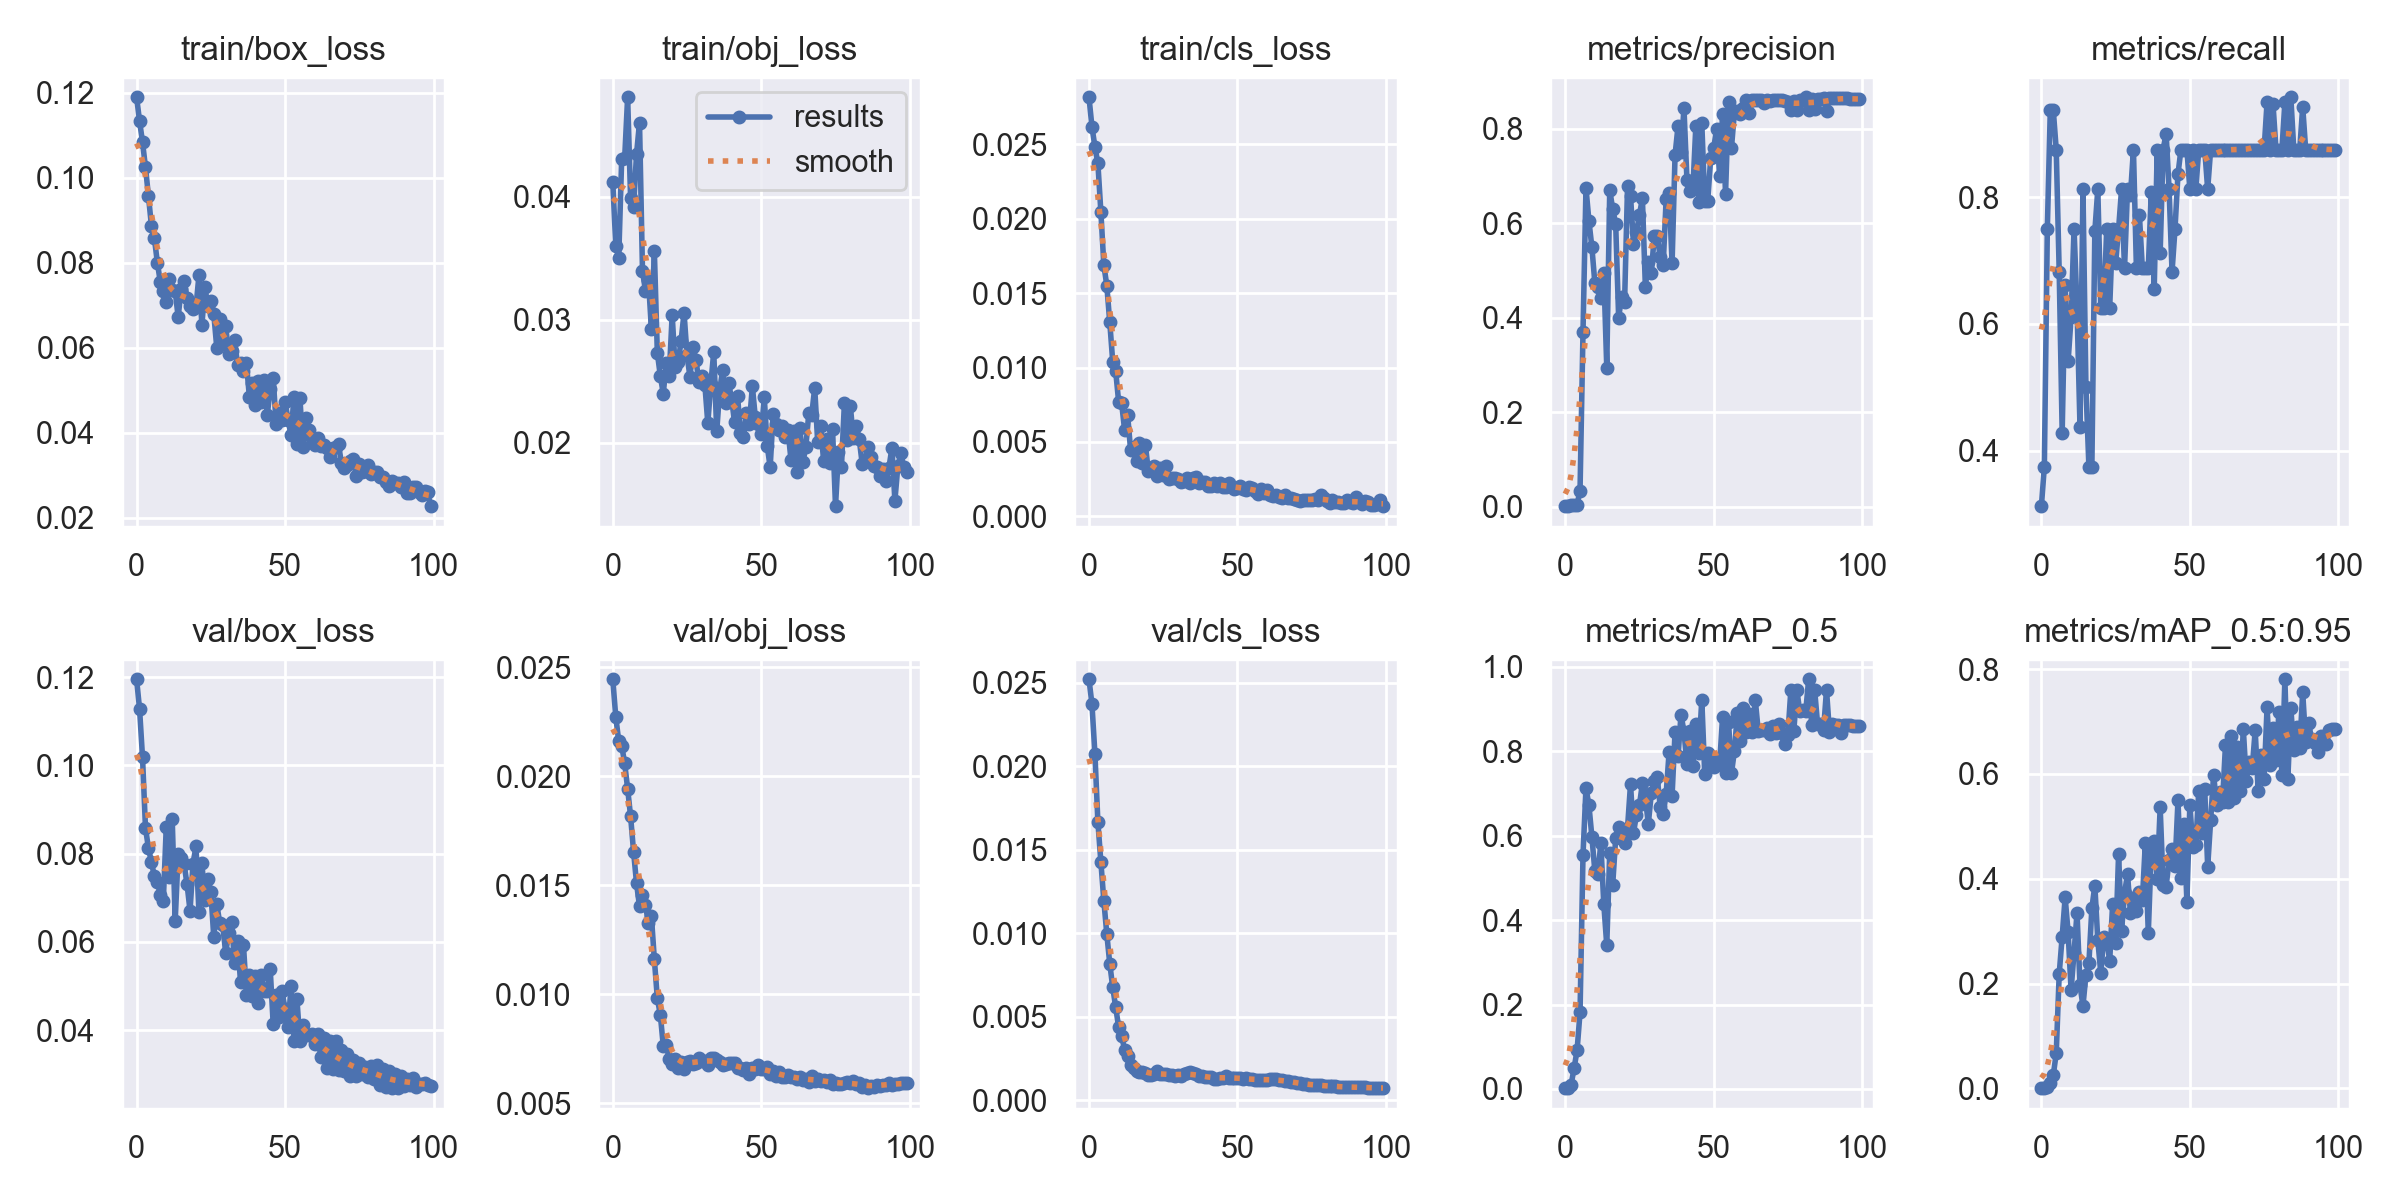

In [8]:
# Curvas do treino: perdas e métricas ao longo das 100 épocas (o joelho da curva mostra onde parou de melhorar)
from IPython.display import Image
Image('/content/yolov5/runs/train/vaca_caminhao/results.png')

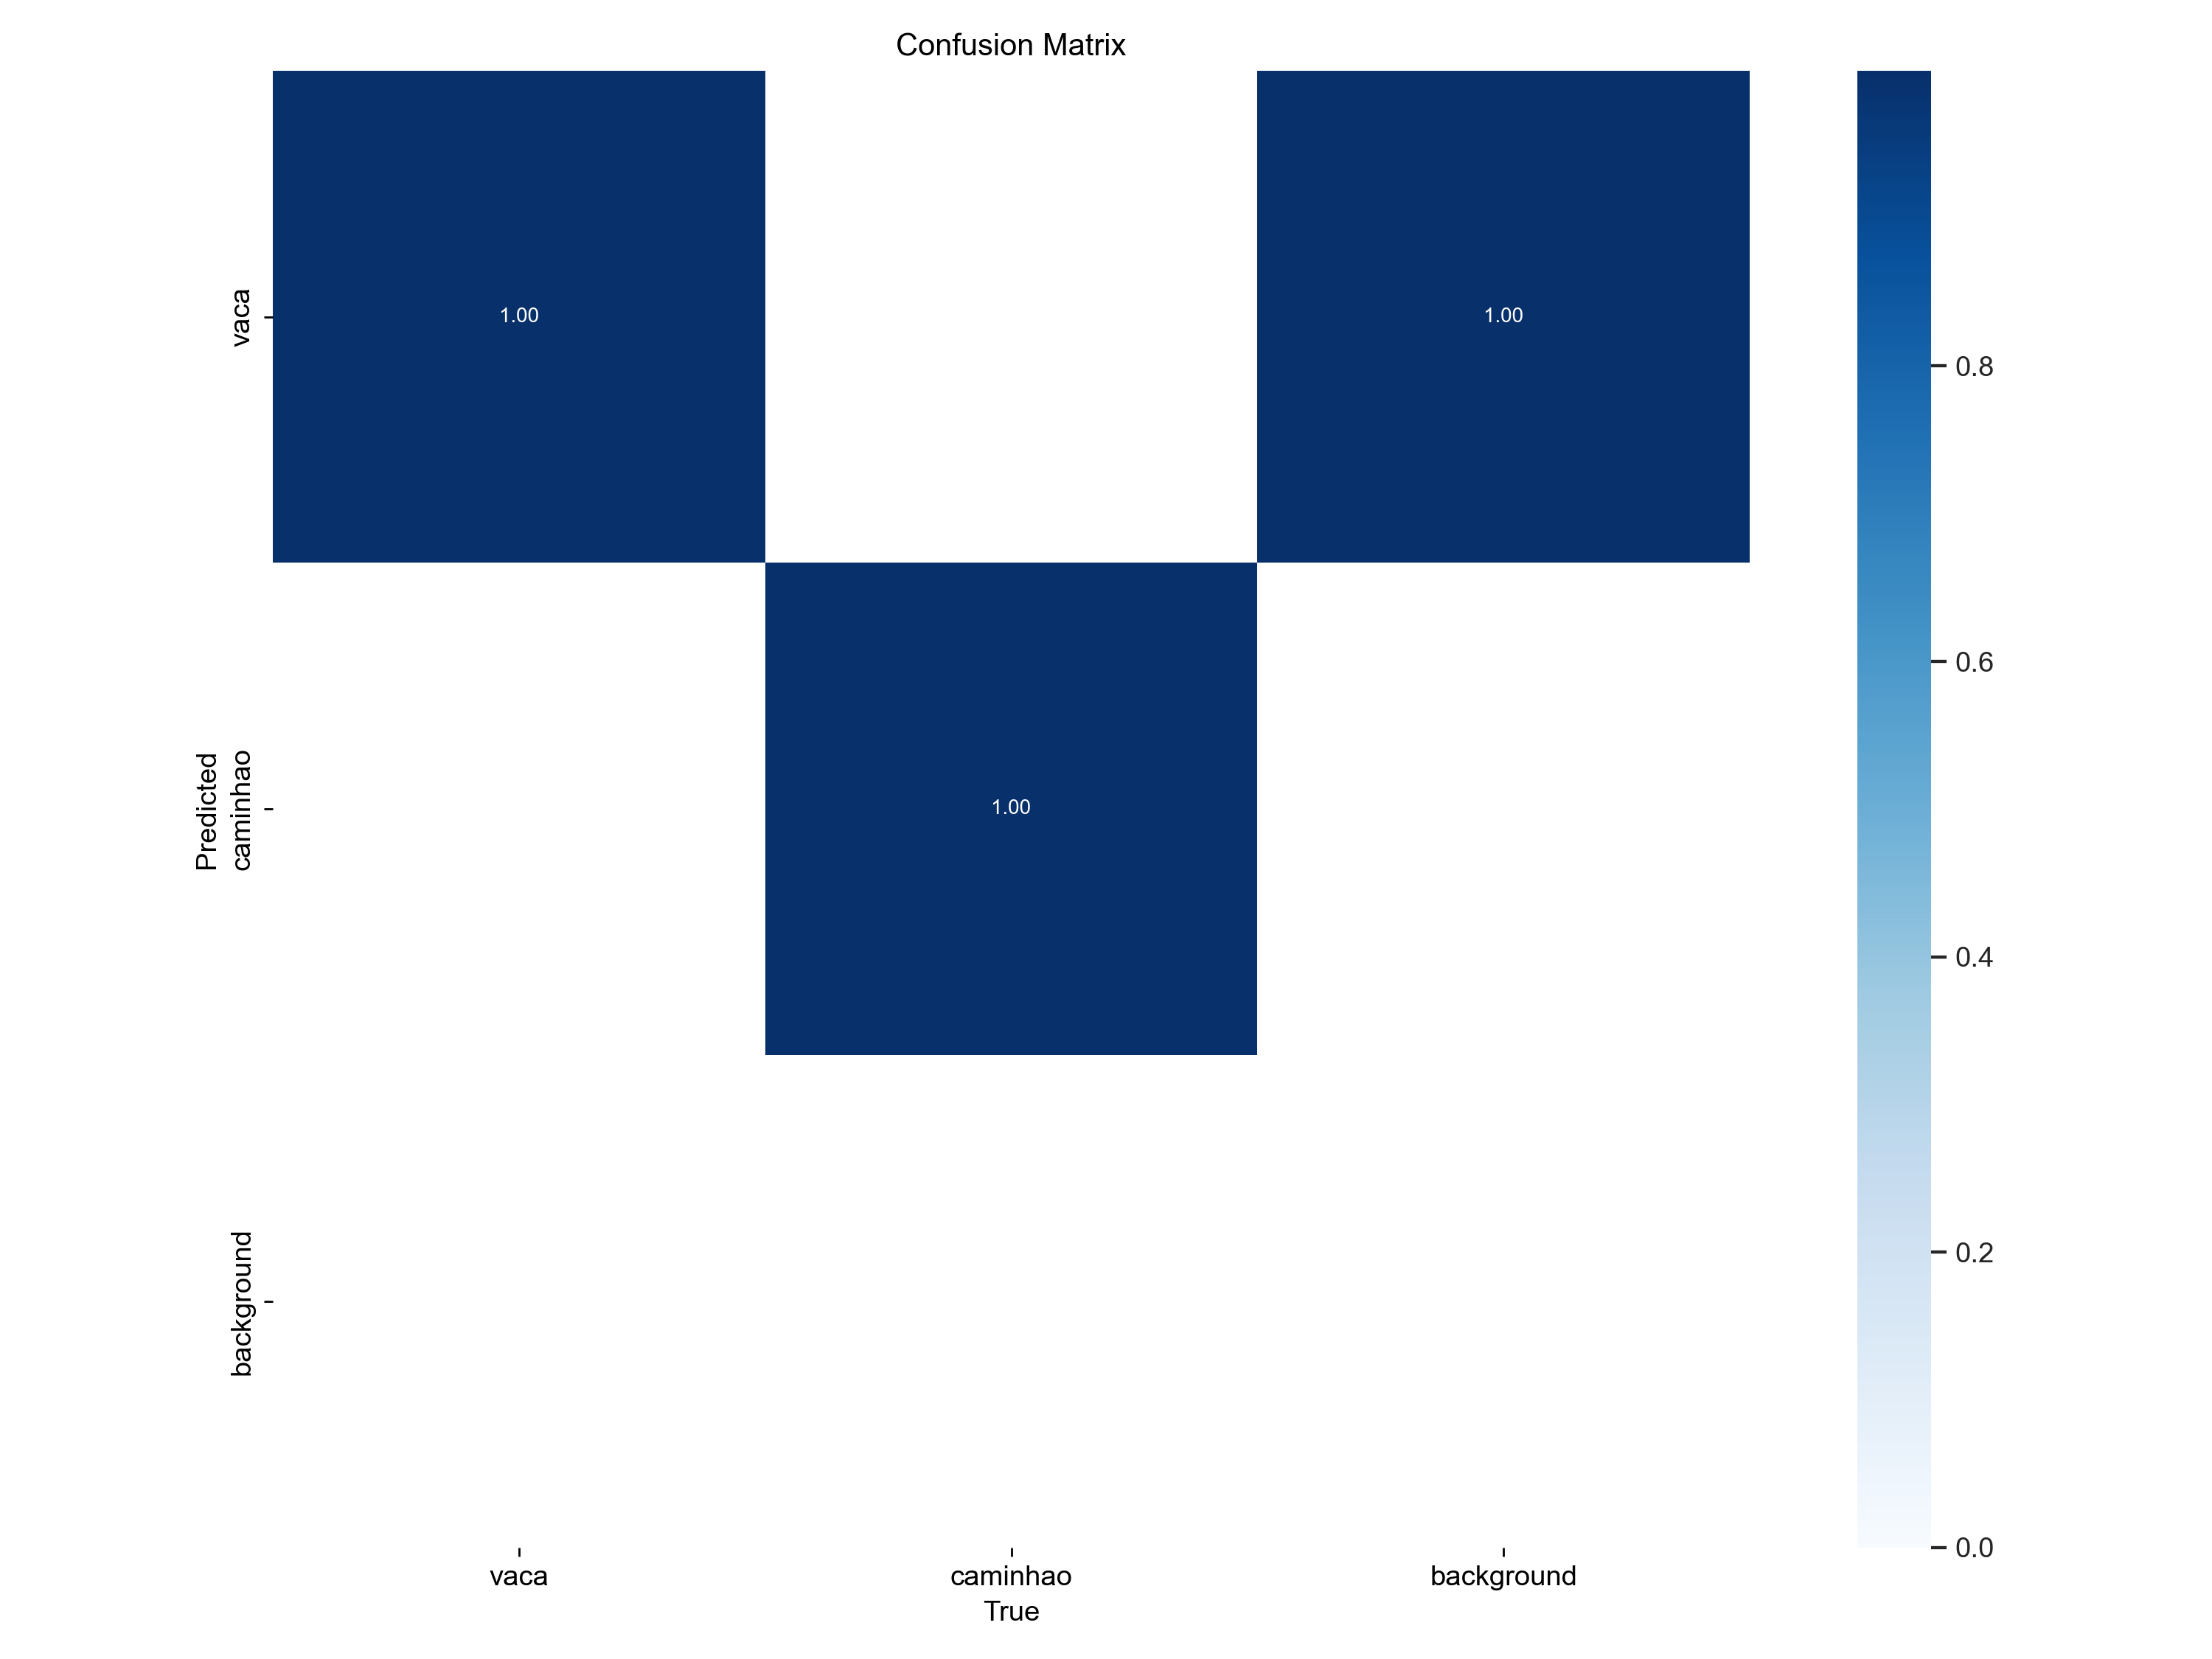

In [9]:
# Matriz de confusão: quantas vacas/caminhões o modelo acerta, confunde entre si ou perde para o fundo
Image('/content/yolov5/runs/train/vaca_caminhao/confusion_matrix.png')

### Avaliação no conjunto de teste (imagens que o modelo nunca viu)

`val.py --task test` usa a chave `test:` do `data.yaml` e reporta P, R, mAP@0.5 e mAP@0.5:0.95 por classe — é o número que vale para o cliente, porque o `best.pt` foi escolhido pela validação.

In [10]:
# Métrica final no teste (8 imagens, 15 instâncias) com o best.pt escolhido pela validação
!python val.py --weights runs/train/vaca_caminhao/weights/best.pt --data /content/dataset/data.yaml --task test --img 640 --name teste_final --exist-ok

val: data=/content/dataset/data.yaml, weights=['runs/train/vaca_caminhao/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=teste_final, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/dataset/labels/test... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 183.6it/s 0.0s
test: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all          8         15      0.821      0.909      0.887      0.579
                  vaca          8      

## 6. Inferência com o modelo treinado

`detect.py` roda o `best.pt` nas imagens de teste e salva as imagens com as caixas em `runs/detect/custom_test/` — é o material que mostramos ao cliente. O log traz também o **tempo de inferência por imagem** (~18 ms na T4), usado depois na comparação da Entrega 2.

In [11]:
# Inferência no teste com o modelo treinado (conf 0.25, igual ao baseline COCO, para comparação justa)
!python detect.py --weights runs/train/vaca_caminhao/weights/best.pt --source /content/dataset/images/test --conf 0.25 --name custom_test --exist-ok

detect: weights=['runs/train/vaca_caminhao/weights/best.pt'], source=/content/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=custom_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/dataset/images/test/caminhao_002.jpg: 640x640 1 caminhao, 14.2ms
image 2/8 /content/dataset/images/test/caminhao_006.jpg: 384x640 1 caminhao, 29.3ms
image 3/8 /content/dataset/images/test/caminhao_017.jpg: 448x640 1 caminhao, 27.4ms
image 4/8 /content/dataset/images/test/caminhao_019

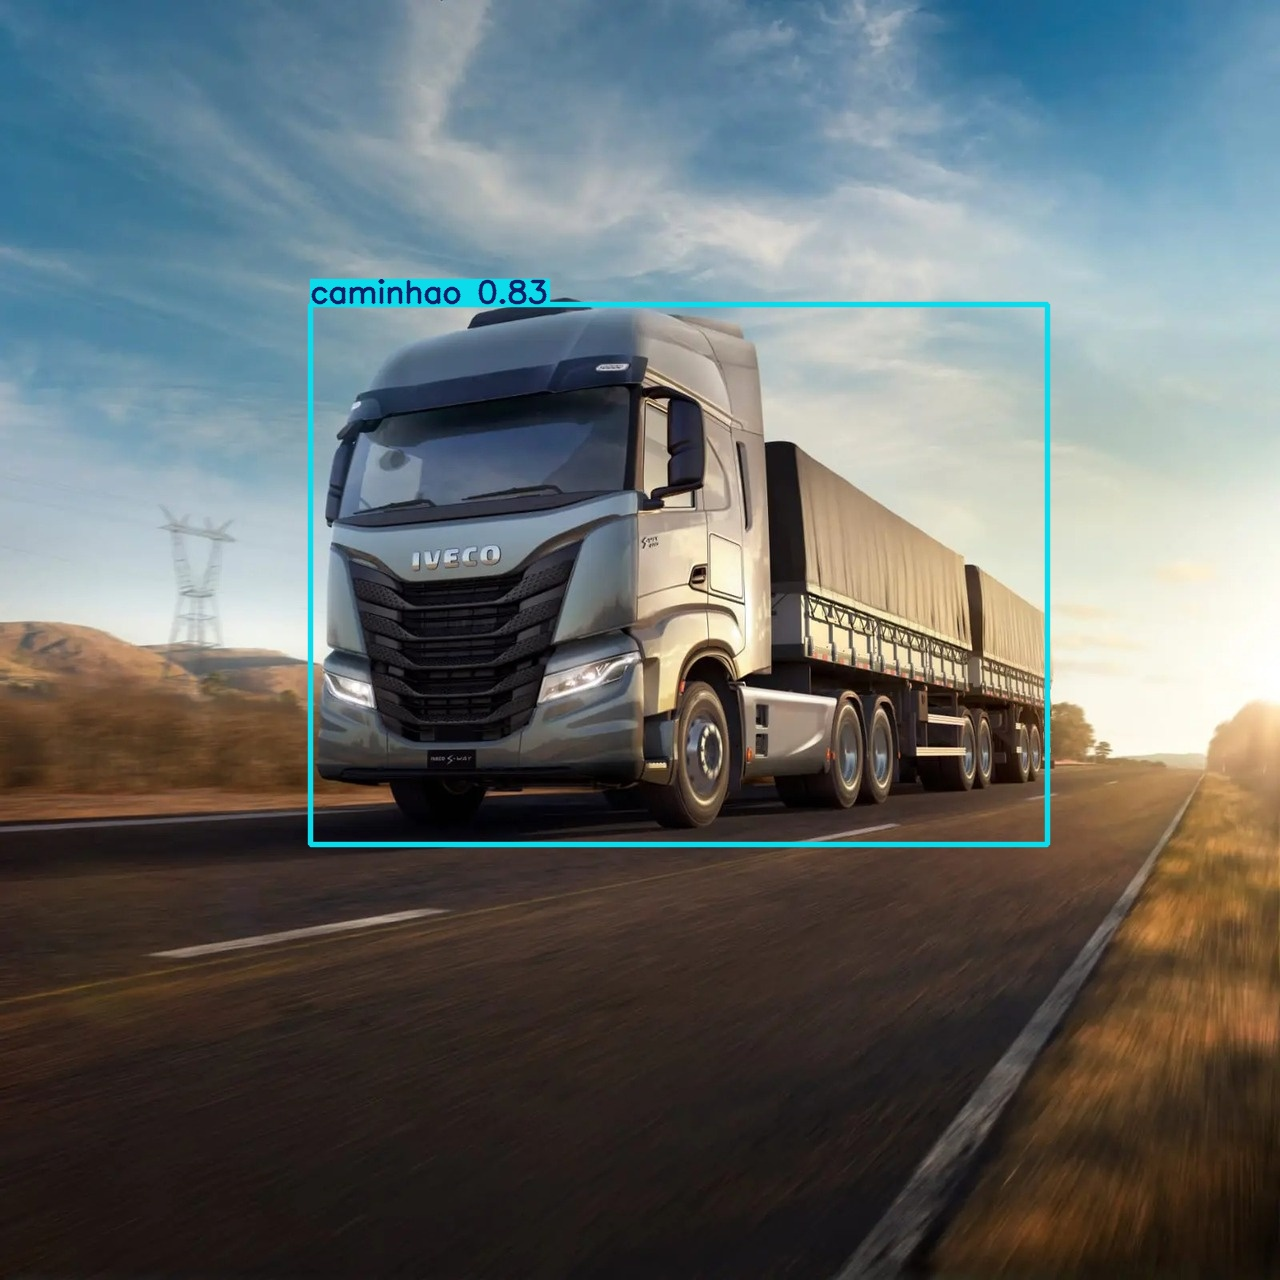

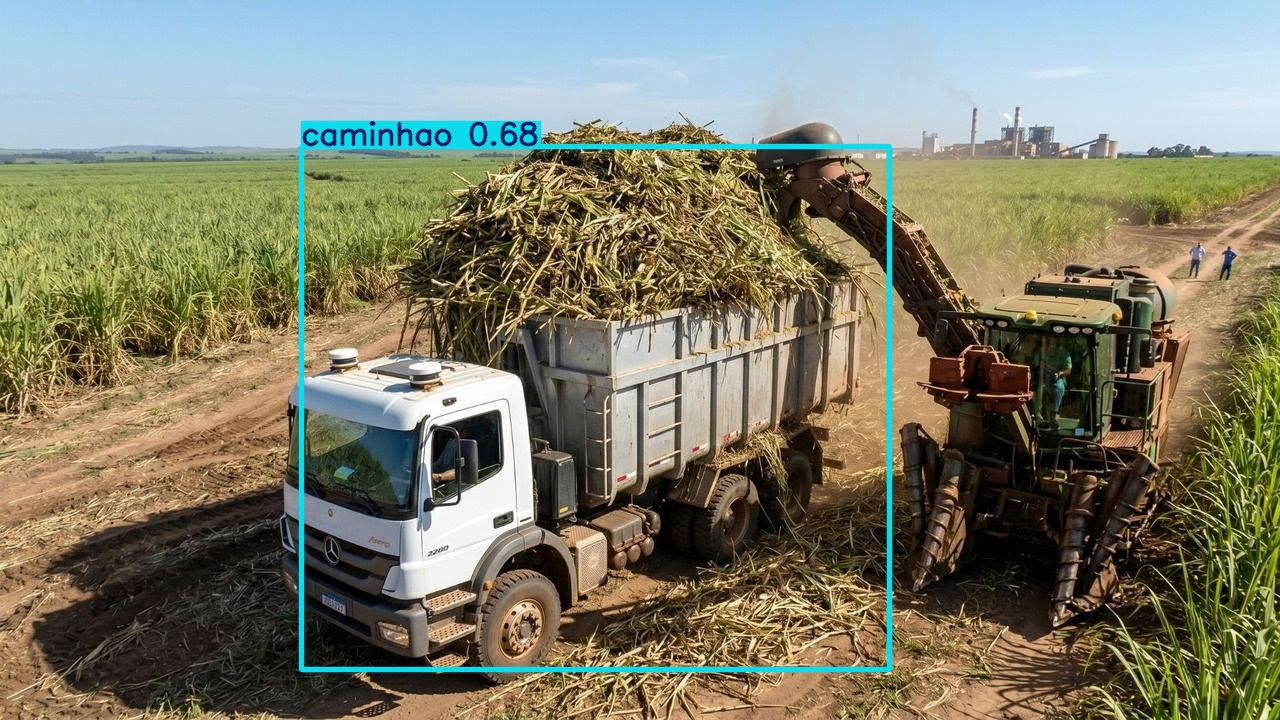

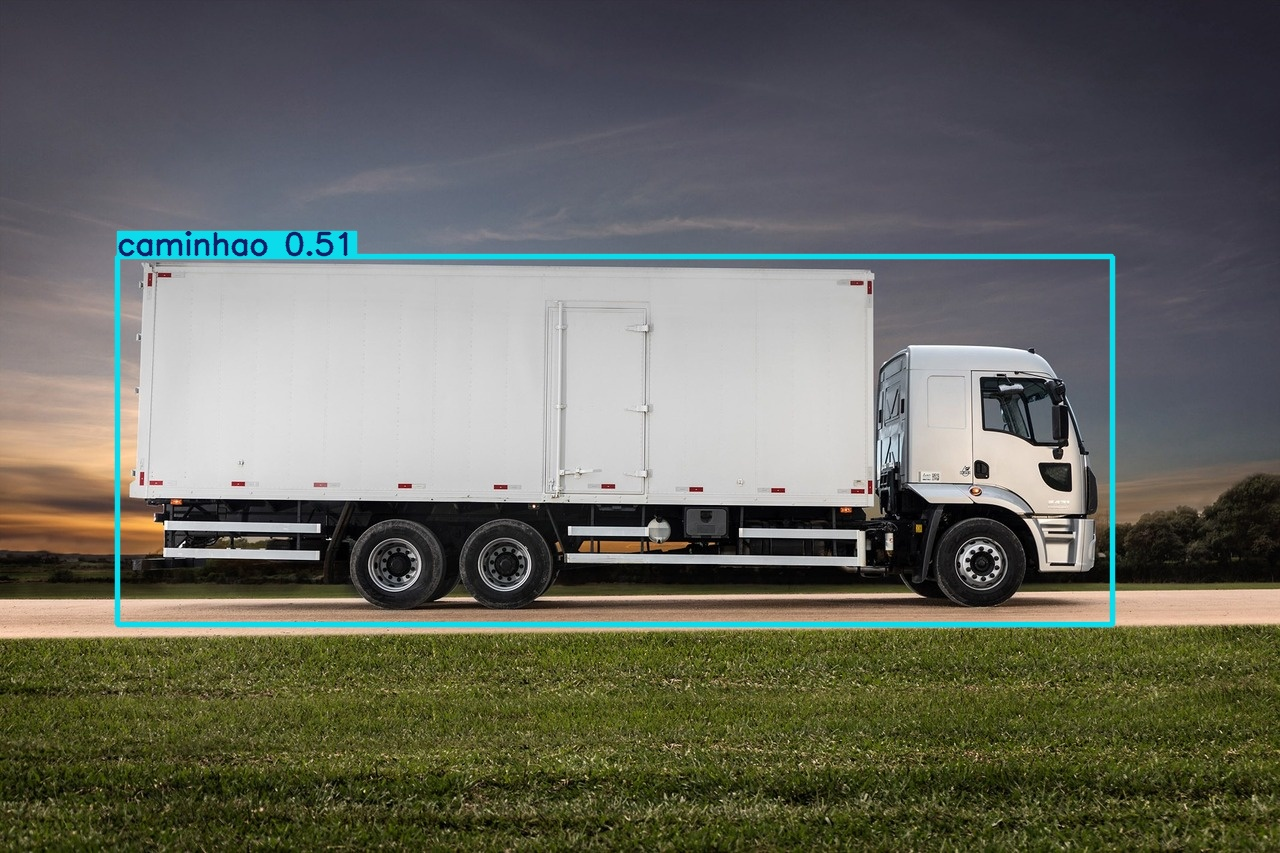

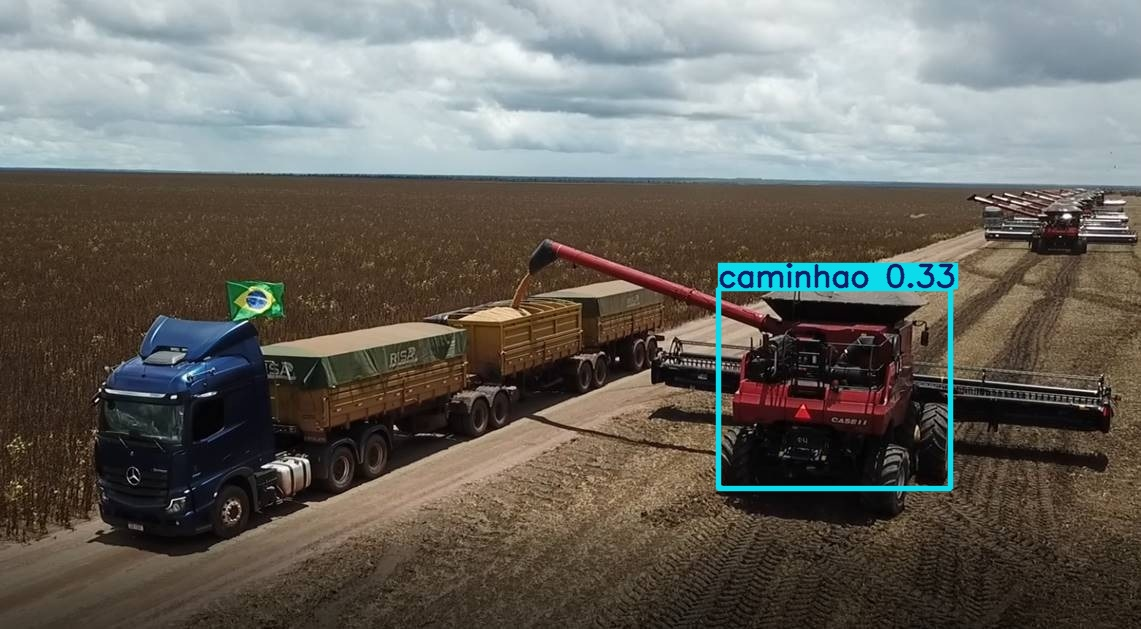

In [12]:
# Prints do teste: as 4 primeiras em ordem alfabética eram todas de caminhão, então mostramos 2 de cada classe
import glob
from IPython.display import Image
imagens = sorted(glob.glob('/content/yolov5/runs/detect/custom_test/*.jpg'))
for classe in ('caminhao', 'vaca'):
    for p in [i for i in imagens if classe in i][:2]:
        display(Image(p))

## 7. Comparação e conclusões

### Resultados

| | Val (8 img, 12 inst.) | Teste (8 img, 15 inst.) |
|---|---|---|
| Precision (geral) | 0,840 | 0,821 |
| Recall (geral) | 0,949 | 0,909 |
| mAP@0.5 | 0,970 | 0,887 |
| mAP@0.5:0.95 | 0,770 | 0,579 |

Por classe no **teste**: vaca (11 instâncias) P 0,854 / R 0,818 / mAP50 0,880 / mAP50-95 0,664; caminhão (4 instâncias) P 0,789 / R 1,0 / mAP50 0,895 / mAP50-95 0,494.

O treino (100 epochs, GPU T4) levou cerca de 5 minutos. O número de referência é o do **teste**: o `best.pt` foi escolhido pela validação, então os valores de val são otimistas.

### YOLO tradicional (COCO) × YOLO customizado

- **Contagem:** o modelo COCO detecta cada parte como um objeto. Em caminhões articulados, por exemplo, contou até 4 "trucks" numa única imagem (`caminhao_019`), enquanto o modelo customizado devolveu 1 caixa por conjunto, que é a convenção usada na rotulagem.
- **Classes:** o baseline foi rodado filtrado em `cow`/`truck` (`--classes 19 7`), as duas classes do COCO que correspondem aos nossos objetos. O modelo customizado aprendeu o critério do nosso dataset (por exemplo, picape contada como caminhão), e por isso responde a nossa pergunta, não a do COCO.
- **Rebanhos:** no teste, o COCO chegou a 9 detecções em `vaca_013`, o customizado a 7. Em rebanhos densos nem todos os animais foram rotulados, o que torna essa comparação imprecisa.
- **Ponto de partida:** o treino usou `yolov5s.pt` (pesos do COCO) como base (transfer learning). Boa parte do resultado vem desse conhecimento prévio, não só das 80 imagens.

### Limitações

- Dataset muito pequeno: 64 imagens de treino, 8 de validação e 8 de teste. O teste tem só 4 caminhões, então uma única caixa errada muda bastante as métricas. Os números são indicativos, não conclusivos.
- mAP50-95 do caminhão (0,494) bem abaixo do mAP50 (0,895): o modelo acha o caminhão, mas as caixas são menos justas, em parte pela ambiguidade de onde termina o conjunto cavalo + carreta.
- Em `vaca_012` e `vaca_035` o modelo customizado detectou 2 vacas onde havia 1 caixa rotulada; a `vaca_012` está nos prints acima e a `vaca_035` pode ser aberta em `custom_test/` (falso positivo ou animal não rotulado).
- Imagens vindas da web, algumas com marca d'água, e rebanhos densos só parcialmente rotulados.
- Uma única execução de treino, sem repetição com outras sementes ou divisões.

### Conclusão

Com poucas imagens, o fine-tuning já entrega um detector das duas classes com mAP@0.5 de 0,887 no teste e recall de 0,909, e segue a convenção de rotulagem do projeto, algo que o COCO sem treino não faz. Para melhorar: mais imagens (principalmente caminhões e rebanhos), rotulagem mais consistente e validação com divisão maior ou cruzada.

### Pendências antes da entrega

- **Re-executar no Colab** as células **3, 5, 7 e 21**: elas foram ajustadas depois da última execução (clonagem idempotente do YOLOv5, checagem do dataset + contagem de caixas por classe, amostra com seed e caixas na escala certa, prints 2 por classe). As saídas salvas nelas são da versão anterior do código.
- Segunda simulação de treino (**30 × 60 épocas**, issue #4), **CNN treinada do zero** (issue #7) e a tabela dos **4 critérios** da Entrega 2 (issue #8) ainda não estão neste notebook.


In [13]:
# Guarda no Drive o que o notebook gerou (runs/ com pesos, results.csv, gráficos e imagens detectadas)
dest = f'{DRIVE_ROOT}/resultados'
shutil.copytree('/content/yolov5/runs', dest, dirs_exist_ok=True)
print('salvo em', dest)

salvo em /content/drive/MyDrive/Espaço Matopiba/Fase 6 - Cap 1/resultados_patrick
